# Modelagem — Câncer Cervical

**Dataset:** [Cervical Cancer (Risk Factors)](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors) — UCI Machine Learning Repository

**Variável-alvo:** `Biopsy` (0 = biópsia negativa, 1 = biópsia positiva)

**Objetivo desta etapa:** treinar, comparar e avaliar modelos de classificação para
prever `Biopsy`, usando os dados já tratados nas etapas anteriores (`01_eda.ipynb` e
`02_preprocessing.ipynb`). Esta é **apenas a etapa de modelagem/avaliação**. Deploy,
interpretabilidade avançada (SHAP/LIME) e construção de pipeline de produção ficam
para notebooks futuros.

### O que já foi decidido nas etapas anteriores (resumo)

1. **Valores ausentes:** colunas com mais de 90% de nulos foram removidas; as demais
   foram imputadas (mediana para numéricas, moda para binárias), ajustando o
   imputador apenas no treino.
2. **Data leakage:** `Hinselmann`, `Schiller`, `Citology`, `Dx`, `Dx:Cancer`,
   `Dx:CIN` e `Dx:HPV` já foram removidas do conjunto preditor.
3. **Assimetria:** `Number of sexual partners` e `Num of pregnancies` já passaram
   por transformação `log1p`.
4. **Padronização:** variáveis numéricas contínuas já foram padronizadas
   (`StandardScaler`); binárias permanecem como estão.
5. **Split treino/teste:** já foi feito de forma estratificada, antes de qualquer
   ajuste de imputação/padronização.
6. **Balanceamento de classes:** ainda **não** foi aplicado — é o primeiro passo
   desta etapa, e deve ser feito somente sobre o treino.

### Sobre a escolha dos 3 classificadores

O enunciado desta etapa pede "Logistic Regression, decision forest e Random" como os
três classificadores de baseline. Interpretamos isso como um pequeno lapso de
digitação e usamos: **Regressão Logística**, **Árvore de Decisão (Decision Tree)** e
**Random Forest** — três modelos com naturezas bem diferentes (linear, árvore única,
ensemble de árvores), o que torna a comparação mais informativa.

Este notebook foi desenvolvido para rodar no **Google Colab**, usando `pandas`,
`numpy`, `scikit-learn`, `matplotlib`, `seaborn` e `imbalanced-learn` (para SMOTE).


## 0. Configuração do ambiente

`imbalanced-learn` não vem pré-instalada no Colab (diferente de pandas/numpy/scikit-learn), então garantimos sua instalação antes de importar.

In [1]:
try:
    import imblearn  # noqa: F401
except ImportError:
    %pip install -q imbalanced-learn
    import imblearn  # noqa: F401

print("imbalanced-learn disponível:", imblearn.__version__)


imbalanced-learn disponível: 0.12.4


In [2]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import (
    f1_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

# Aviso de compatibilidade interna entre versões do scikit-learn e do
# imbalanced-learn (não afeta o resultado) — silenciado para manter a saída limpa.
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 1. Carregamento dos Dados Processados

Carregamos os conjuntos de treino e teste já tratados no notebook anterior. Também
lemos o `preprocessing_metadata.json` apenas como **referência de contexto** (para
lembrar quais colunas foram transformadas e como) — nada daquela etapa é reajustado
aqui.

In [3]:
TRAIN_PATH = "../data/processed/cervical_cancer_train_processed.csv"
TEST_PATH = "../data/processed/cervical_cancer_test_processed.csv"
METADATA_PATH = "../models/preprocessing_metadata.json"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadados_preprocessamento = json.load(f)

TARGET = metadados_preprocessamento["target"]

print("Contexto do pré-processamento (apenas referência):")
print(f"- Colunas numéricas padronizadas: {len(metadados_preprocessamento['colunas_numericas'])}")
print(f"- Colunas binárias: {len(metadados_preprocessamento['colunas_binarias'])}")
print(f"- Colunas com log1p: {metadados_preprocessamento['colunas_assimetricas_log1p']}")


Contexto do pré-processamento (apenas referência):
- Colunas numéricas padronizadas: 10
- Colunas binárias: 16
- Colunas com log1p: ['Number of sexual partners', 'Num of pregnancies']


In [4]:
X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

print(f"Treino: {X_train.shape[0]} linhas x {X_train.shape[1]} colunas")
print(f"Teste:  {X_test.shape[0]} linhas x {X_test.shape[1]} colunas")
print()
print("Valores nulos no treino:", X_train.isnull().sum().sum())
print("Valores nulos no teste: ", X_test.isnull().sum().sum())
print()
print(f"Proporção de positivos no treino: {y_train.mean() * 100:.2f}% ({y_train.sum()} de {len(y_train)})")
print(f"Proporção de positivos no teste:  {y_test.mean() * 100:.2f}% ({y_test.sum()} de {len(y_test)})")


Treino: 686 linhas x 26 colunas
Teste:  172 linhas x 26 colunas

Valores nulos no treino: 0
Valores nulos no teste:  0

Proporção de positivos no treino: 6.41% (44 de 686)
Proporção de positivos no teste:  6.40% (11 de 172)


**Confirmação:** os dados chegam sem nulos e com a mesma proporção de classes
observada na etapa de pré-processamento — o split estratificado funcionou como
esperado, e ainda não há nenhum balanceamento aplicado (a proporção de positivos no
treino é a original, ~6%).

## 2. Balanceamento de Classes

### Por que balancear, e por que só no treino

A EDA e o pré-processamento já mostraram que `Biopsy` é bastante desbalanceada
(cerca de 6% de positivos). Sem tratamento, a maioria dos classificadores tende a
"aprender" que prever sempre a classe negativa já dá uma acurácia alta — o que é
inútil clinicamente, já que o objetivo é justamente identificar os casos raros de
risco.

**Decisão: aplicar SMOTE (Synthetic Minority Oversampling Technique) somente no
conjunto de treino.**

**Por que o teste permanece com a distribuição original:** o conjunto de teste existe
para simular como o modelo se comportaria com pacientes reais e novos — e, na
população real, os casos positivos são raros. Se aplicássemos SMOTE (ou qualquer
balanceamento) no teste, estaríamos avaliando o modelo em uma realidade artificial que
não existe na prática, o que infla as métricas e engana sobre a real capacidade do
modelo. Por isso, balanceamento é uma técnica de **treino**, não de **avaliação**.

### Um cuidado técnico importante

Vamos primeiro aplicar o SMOTE uma única vez sobre todo o treino, **apenas para fins
de visualização** — para mostrar o efeito da técnica. Mas esse conjunto reamostrado
**não** será usado diretamente para treinar os modelos da Seção 4. Em vez disso,
usaremos um `Pipeline` do `imbalanced-learn` que aplica o SMOTE **dentro de cada fold**
da validação cruzada. Isso evita um erro sutil e comum: se o SMOTE for aplicado antes
de dividir os dados em folds de validação cruzada, exemplos sintéticos podem ser
gerados a partir de vizinhos que acabam "vazando" entre o fold de treino e o fold de
validação, inflando artificialmente as métricas.

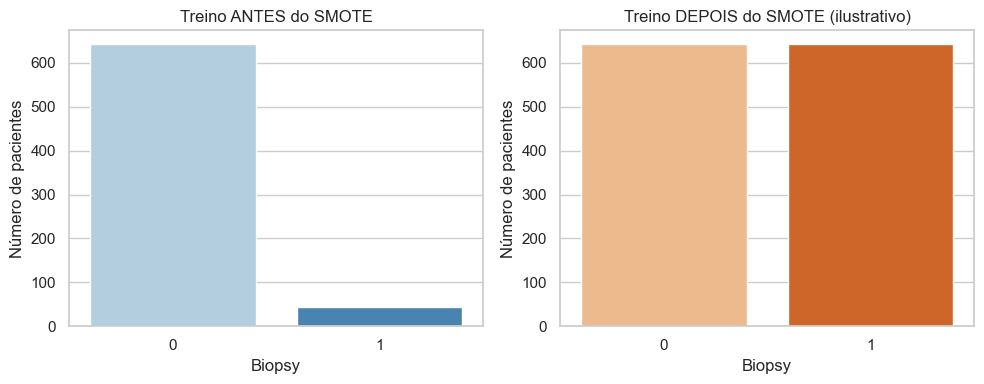

Antes do SMOTE: {0: 642, 1: 44}
Depois do SMOTE: {0: 642, 1: 642}


In [5]:
smote_ilustrativo = SMOTE(random_state=RANDOM_STATE)
X_train_ilustrativo, y_train_ilustrativo = smote_ilustrativo.fit_resample(X_train, y_train)

contagem_antes = y_train.value_counts().sort_index()
contagem_depois = y_train_ilustrativo.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=contagem_antes.index.astype(str), y=contagem_antes.values, hue=contagem_antes.index.astype(str), legend=False, ax=axes[0], palette="Blues")
axes[0].set_title("Treino ANTES do SMOTE")
axes[0].set_xlabel("Biopsy")
axes[0].set_ylabel("Número de pacientes")

sns.barplot(x=contagem_depois.index.astype(str), y=contagem_depois.values, hue=contagem_depois.index.astype(str), legend=False, ax=axes[1], palette="Oranges")
axes[1].set_title("Treino DEPOIS do SMOTE (ilustrativo)")
axes[1].set_xlabel("Biopsy")
axes[1].set_ylabel("Número de pacientes")

plt.tight_layout()
plt.show()

print("Antes do SMOTE:", contagem_antes.to_dict())
print("Depois do SMOTE:", contagem_depois.to_dict())


**Interpretação:** antes do SMOTE, a classe positiva é uma pequena fração do treino.
Depois, as duas classes ficam com o mesmo tamanho — os exemplos positivos adicionais
são sintéticos, criados por interpolação entre exemplos reais da classe minoritária
existentes no treino, e não pacientes reais novos. Esse conjunto ilustrativo não é
reaproveitado adiante; o SMOTE "de verdade" é aplicado dentro de cada fold, como
explicado acima.

## 3. Definição da Estratégia de Validação

**Decisão: `StratifiedKFold` com 5 folds.**

**Por que estratificado:** com apenas ~6% de casos positivos no treino, uma divisão
comum (não estratificada) em folds poderia, por azar, deixar algum fold quase sem
exemplos positivos — tornando a métrica calculada naquele fold instável ou sem
sentido. O `StratifiedKFold` garante que cada fold mantenha aproximadamente a mesma
proporção de positivos e negativos do treino completo.

**Por que 5 folds:** o treino tem poucas dezenas de casos positivos no total. Usar
muitos folds (ex.: 10) deixaria poucos exemplos positivos em cada fold de validação,
tornando a métrica ruidosa. Usar poucos folds (ex.: 3) daria uma estimativa menos
robusta, com validações muito grandes e menos variação para observar a estabilidade do
modelo. Cinco folds é um meio-termo comum e equilibrado, que ainda garante um número
razoável de exemplos positivos em cada fold de validação.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Confirma visualmente que cada fold preserva a proporção de positivos
for i, (idx_treino, idx_validacao) in enumerate(cv.split(X_train, y_train), start=1):
    proporcao_fold = y_train.iloc[idx_validacao].mean() * 100
    print(f"Fold {i}: {len(idx_validacao)} exemplos de validação, {proporcao_fold:.2f}% positivos")


Fold 1: 138 exemplos de validação, 6.52% positivos
Fold 2: 137 exemplos de validação, 5.84% positivos
Fold 3: 137 exemplos de validação, 6.57% positivos
Fold 4: 137 exemplos de validação, 6.57% positivos
Fold 5: 137 exemplos de validação, 6.57% positivos


## 4. Treinamento dos Modelos (Baseline)

Cada modelo é envolvido em um `Pipeline` que aplica o SMOTE apenas na parte de treino
de cada fold (como explicado na Seção 2) e depois treina o classificador. Usamos um
laço (`for`) para treinar e avaliar os três modelos com o mesmo código, evitando
repetição.

In [7]:
modelos_base = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
}

# Métricas priorizadas por conta do desbalanceamento de classes (ver Seção 5)
metricas_avaliacao = {
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "auc_pr": "average_precision",
}

def construir_pipeline(modelo):
    """Monta um pipeline que aplica SMOTE apenas no treino de cada fold."""
    return ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classificador", modelo),
    ])

resultados_cv = {}
linhas_resumo = []

for nome_modelo, modelo in modelos_base.items():
    pipeline = construir_pipeline(modelo)
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=metricas_avaliacao, n_jobs=-1
    )
    resultados_cv[nome_modelo] = scores
    linhas_resumo.append({
        "Modelo": nome_modelo,
        "F1 (média)": scores["test_f1"].mean(),
        "Recall (média)": scores["test_recall"].mean(),
        "AUC-ROC (média)": scores["test_roc_auc"].mean(),
        "AUC-PR (média)": scores["test_auc_pr"].mean(),
    })

print("Treinamento e validação cruzada concluídos para os 3 modelos.")


Treinamento e validação cruzada concluídos para os 3 modelos.


## 5. Métricas de Avaliação

### Por que priorizar Recall e AUC-PR neste contexto clínico

Neste problema, um **falso negativo** (o modelo prever "sem risco" para uma paciente
que na verdade tem biópsia positiva) é um erro muito mais grave do que um **falso
positivo** (encaminhar para investigação adicional uma paciente que não tinha a
condição). O primeiro pode atrasar um diagnóstico importante; o segundo, na pior das
hipóteses, gera um exame a mais.

- **Recall** mede a proporção de casos positivos reais que o modelo conseguiu
  identificar — diretamente relacionado a "quantos casos de risco não deixamos
  passar".
- **AUC-PR** (área sob a curva Precision-Recall) é mais informativa que a AUC-ROC
  tradicional quando a classe positiva é rara: a AUC-ROC pode parecer "boa" mesmo
  com muitos falsos positivos, porque é dominada pela grande quantidade de
  verdadeiros negativos. A AUC-PR foca exatamente na capacidade do modelo de
  encontrar a classe minoritária sem gerar alarmes em excesso.
- **F1-score** e **AUC-ROC** são reportados como métricas complementares, para dar
  uma visão mais completa do equilíbrio entre precisão e recall.

In [8]:
tabela_resultados = pd.DataFrame(linhas_resumo).sort_values("AUC-PR (média)", ascending=False).reset_index(drop=True)
tabela_resultados


,Modelo,F1 (média),Recall (média),AUC-ROC (média),AUC-PR (média)
0,Random Forest,0.149697,0.113889,0.620979,0.224011
1,Regressão Logística,0.138630,0.402778,0.599946,0.115984
2,Árvore de Decisão,0.195438,0.227778,0.577089,0.107246


**Leitura da tabela (trade-off real entre as métricas):** os três modelos não
concordam entre si. O **Random Forest** tem a melhor AUC-PR, mas um **Recall baixo**
(captura poucos dos casos positivos reais). A **Regressão Logística** é o oposto: tem
o **melhor Recall**, mas a pior AUC-PR. A **Árvore de Decisão** fica no meio, com o
melhor F1-score isolado.

Isso acontece porque Recall é medido em um único limiar de decisão (0,5, o padrão),
enquanto AUC-PR resume a qualidade do modelo em *todos* os limiares possíveis. Um
modelo pode "ordenar" bem os pacientes por risco (boa AUC-PR) e, ainda assim, marcar
poucos como positivos no limiar padrão (Recall baixo) — nesse caso, calibrar o limiar
de decisão (não feito neste notebook, ver Seção 8) tende a ser mais eficaz do que
trocar de modelo.

Mantemos a AUC-PR como critério principal de seleção (Seção 6), por ser mais robusta
e não depender de um limiar específico — mas deixamos registrado que, no limiar
padrão, o modelo escolhido ainda tem Recall baixo, o que é uma limitação real a ser
tratada antes de qualquer uso clínico.

### Matriz de confusão do melhor modelo (validação cruzada)

Para visualizar os erros do modelo com melhor AUC-PR média, geramos previsões fora da amostra (*out-of-fold*) via `cross_val_predict`, usando o conjunto de treino inteiro — o conjunto de teste continua intocado, para ser usado uma única vez na Seção 6.

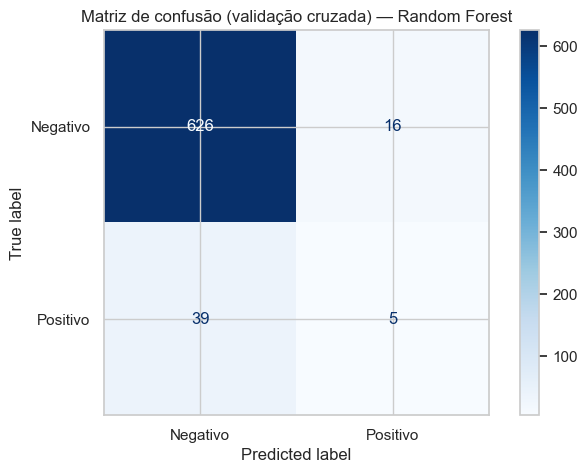

              precision    recall  f1-score   support

    Negativo       0.94      0.98      0.96       642
    Positivo       0.24      0.11      0.15        44

    accuracy                           0.92       686
   macro avg       0.59      0.54      0.56       686
weighted avg       0.90      0.92      0.91       686



In [9]:
nome_melhor_baseline = tabela_resultados.iloc[0]["Modelo"]
pipeline_melhor_baseline = construir_pipeline(modelos_base[nome_melhor_baseline])

y_pred_cv = cross_val_predict(pipeline_melhor_baseline, X_train, y_train, cv=cv, n_jobs=-1)

matriz = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(matriz, display_labels=["Negativo", "Positivo"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusão (validação cruzada) — {nome_melhor_baseline}")
plt.show()

print(classification_report(y_train, y_pred_cv, target_names=["Negativo", "Positivo"]))


## 6. Seleção e Ajuste do Modelo Final

Selecionamos o modelo com melhor **AUC-PR média** na validação cruzada (métrica mais
adequada ao desbalanceamento, como discutido na Seção 5) para passar por um ajuste
simples de hiperparâmetros via `GridSearchCV`. A busca também usa o mesmo `Pipeline`
com SMOTE dentro de cada fold, e o mesmo `StratifiedKFold` de 5 folds definido na
Seção 3.

Como discutido logo acima, essa escolha prioriza a capacidade geral do modelo de
ordenar pacientes por risco, sabendo que o Recall no limiar padrão pode ficar aquém
do ideal — um ponto que retomamos na síntese final (Seção 8).

In [10]:
grades_hiperparametros = {
    "Regressão Logística": {
        "classificador__C": [0.01, 0.1, 1, 10],
        "classificador__solver": ["lbfgs"],
    },
    "Árvore de Decisão": {
        "classificador__max_depth": [3, 5, 8, None],
        "classificador__min_samples_leaf": [1, 5, 10],
    },
    "Random Forest": {
        "classificador__n_estimators": [100, 200, 400],
        "classificador__max_depth": [None, 5, 10],
        "classificador__min_samples_leaf": [1, 5],
    },
}

print(f"Modelo escolhido para ajuste: {nome_melhor_baseline}")
print(f"Grade de hiperparâmetros: {grades_hiperparametros[nome_melhor_baseline]}")


Modelo escolhido para ajuste: Random Forest
Grade de hiperparâmetros: {'classificador__n_estimators': [100, 200, 400], 'classificador__max_depth': [None, 5, 10], 'classificador__min_samples_leaf': [1, 5]}


In [11]:
pipeline_para_ajuste = construir_pipeline(modelos_base[nome_melhor_baseline])

busca_hiperparametros = GridSearchCV(
    pipeline_para_ajuste,
    param_grid=grades_hiperparametros[nome_melhor_baseline],
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

busca_hiperparametros.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", busca_hiperparametros.best_params_)
print(f"Melhor AUC-PR média (validação cruzada): {busca_hiperparametros.best_score_:.4f}")


Melhores hiperparâmetros encontrados: {'classificador__max_depth': None, 'classificador__min_samples_leaf': 1, 'classificador__n_estimators': 400}
Melhor AUC-PR média (validação cruzada): 0.2280


### Avaliação final no conjunto de teste (uma única vez)

Esta é a única vez, em todo o notebook, que o conjunto de teste é usado para calcular
métricas — exatamente para preservá-lo como uma estimativa honesta do desempenho em
dados nunca vistos.

In [12]:
modelo_final = busca_hiperparametros.best_estimator_

y_pred_teste = modelo_final.predict(X_test)
y_proba_teste = modelo_final.predict_proba(X_test)[:, 1]

metricas_teste = {
    "F1-score": f1_score(y_test, y_pred_teste),
    "Recall": recall_score(y_test, y_pred_teste),
    "AUC-ROC": roc_auc_score(y_test, y_proba_teste),
    "AUC-PR": average_precision_score(y_test, y_proba_teste),
}

pd.DataFrame([metricas_teste]).T.rename(columns={0: "Valor no teste"})


,Valor no teste
F1-score,0.133333
Recall,0.090909
AUC-ROC,0.745059
AUC-PR,0.212754


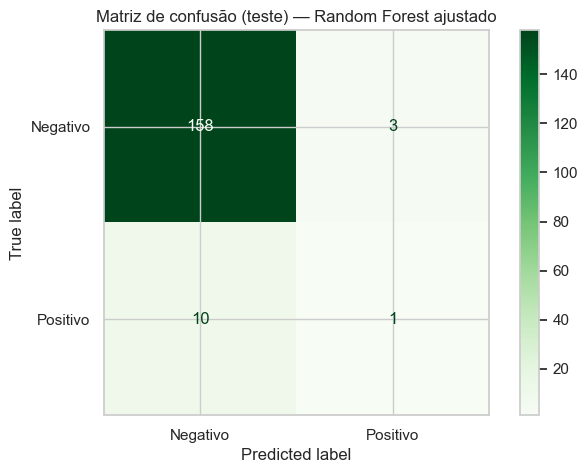

              precision    recall  f1-score   support

    Negativo       0.94      0.98      0.96       161
    Positivo       0.25      0.09      0.13        11

    accuracy                           0.92       172
   macro avg       0.60      0.54      0.55       172
weighted avg       0.90      0.92      0.91       172



In [13]:
matriz_teste = confusion_matrix(y_test, y_pred_teste)
disp_teste = ConfusionMatrixDisplay(matriz_teste, display_labels=["Negativo", "Positivo"])
disp_teste.plot(cmap="Greens", values_format="d")
plt.title(f"Matriz de confusão (teste) — {nome_melhor_baseline} ajustado")
plt.show()

print(classification_report(y_test, y_pred_teste, target_names=["Negativo", "Positivo"]))


## 7. Exportação do Modelo Final

Salvamos o `Pipeline` completo (SMOTE + classificador ajustado) em `/models/`. Isso é
proposital: o `Pipeline` do `imbalanced-learn` já sabe **ignorar automaticamente** a
etapa de SMOTE quando chamado com `.predict()` — o SMOTE só é executado durante
`.fit()`. Ou seja, o arquivo salvo pode ser carregado e usado diretamente para prever
novos pacientes, sem nenhum tratamento especial.

Também salvamos um arquivo de metadados (`modeling_metadata.json`) documentando qual
modelo foi escolhido, seus hiperparâmetros e as métricas obtidas no teste.

**Como reaplicar este modelo em dados novos:** dados novos devem primeiro passar
pelos mesmos passos de pré-processamento do notebook `02_preprocessing.ipynb`
(remover as mesmas colunas, imputar com `imputer_numerico.joblib` /
`imputer_binario.joblib`, aplicar `log1p` nas mesmas colunas, padronizar com
`scaler_numerico.joblib`) — todos salvos em `/models/` na etapa anterior — e só então
serem passados para o modelo salvo aqui.

In [14]:
import re

slug_modelo = re.sub(r"[^a-z0-9]+", "_", nome_melhor_baseline.lower()).strip("_")
caminho_modelo = f"../models/modelo_final_{slug_modelo}.joblib"

joblib.dump(modelo_final, caminho_modelo)

metadados_modelagem = {
    "modelo_escolhido": nome_melhor_baseline,
    "hiperparametros": busca_hiperparametros.best_params_,
    "metrica_usada_para_selecao": "AUC-PR (average_precision) médio em validação cruzada (5 folds estratificados)",
    "metricas_teste": metricas_teste,
    "arquivo_modelo": caminho_modelo,
    "artefatos_de_preprocessamento_necessarios": [
        "../models/imputer_numerico.joblib",
        "../models/imputer_binario.joblib",
        "../models/scaler_numerico.joblib",
        "../models/preprocessing_metadata.json",
    ],
}

with open("../models/modeling_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadados_modelagem, f, ensure_ascii=False, indent=2)

print(f"Modelo final salvo em: {caminho_modelo}")
print("Metadados salvos em: models/modeling_metadata.json")


Modelo final salvo em: ../models/modelo_final_random_forest.joblib
Metadados salvos em: models/modeling_metadata.json


## 8. Síntese da Etapa de Modelagem

*(Os números abaixo foram conferidos na execução completa deste notebook contra os
dados reais — não são valores ilustrativos.)*

**Modelos testados:** Regressão Logística, Árvore de Decisão e Random Forest, todos
treinados com SMOTE aplicado corretamente dentro de cada fold da validação cruzada
estratificada (5 folds), para evitar vazamento de dados sintéticos entre treino e
validação. Resultado da comparação (médias em validação cruzada):

| Modelo | F1 | Recall | AUC-ROC | AUC-PR |
|---|---|---|---|---|
| Random Forest | 0,150 | 0,114 | 0,621 | **0,224** |
| Regressão Logística | 0,139 | **0,403** | 0,600 | 0,116 |
| Árvore de Decisão | **0,195** | 0,228 | 0,577 | 0,107 |

Os três modelos discordam entre si sobre qual métrica priorizam — não há um vencedor
único e óbvio (ver discussão da Seção 5).

**Critério de seleção e modelo escolhido:** usamos AUC-PR média em validação cruzada
como critério principal, por ser mais robusta ao desbalanceamento e não depender de
um limiar fixo de decisão. Isso levou à escolha do **Random Forest**, ajustado via
`GridSearchCV` para `n_estimators=400`, `max_depth=None`, `min_samples_leaf=1`
(AUC-PR média de 0,228 em validação cruzada). Avaliado **uma única vez** no conjunto
de teste: F1 = 0,133, Recall = 0,091, AUC-ROC = 0,745, AUC-PR = 0,213.

**Uma limitação importante para ler os resultados com cautela:** no limiar padrão de
decisão (0,5), o Random Forest escolhido captura apenas 1 dos 11 casos positivos do
teste (Recall ≈ 9%) — bem abaixo do Recall observado na Regressão Logística em
validação cruzada (~40%). Ou seja, o modelo com melhor capacidade de *ranquear*
pacientes por risco (AUC-PR) não é, no limiar padrão, o que *identifica* mais casos
positivos. Isso não invalida a escolha (a AUC-PR alta indica que o modelo consegue
separar risco alto de risco baixo melhor do que os outros, em algum limiar), mas
significa que o modelo **não deveria ser usado com o limiar padrão de 0,5 em um
cenário clínico real** sem antes calibrar esse limiar para priorizar Recall — o
próprio objetivo que motivou usar Recall e AUC-PR como métricas centrais nesta etapa
(Seção 5).

**Limitações identificadas:**
- O número absoluto de casos positivos é pequeno (44 no treino, 11 no teste), o que
  torna qualquer métrica sujeita a bastante variação — os números acima são uma
  estimativa, não um resultado definitivo.
- O limiar de decisão usado (0,5, padrão do `.predict()`) não foi calibrado
  especificamente para este contexto clínico. Dado o Recall baixo observado, essa
  calibração — ajustando o limiar para reduzir falsos negativos, mesmo à custa de mais
  falsos positivos — é a próxima ação mais importante antes de qualquer uso real do
  modelo.
- O SMOTE gera exemplos positivos sintéticos por interpolação; ajuda o modelo a
  aprender padrões da classe minoritária, mas não substitui dados reais adicionais.
  Vale considerar, em iteração futura, comparar esta abordagem com o uso de
  `class_weight="balanced"` nos classificadores (alternativa ao reamostragem), e
  também reavaliar se a Regressão Logística — com Recall bem mais alto — seria uma
  escolha melhor caso o objetivo do projeto priorize explicitamente minimizar falsos
  negativos acima de tudo.
- Interpretabilidade avançada (ex.: SHAP/LIME) e construção de um pipeline de
  produção ficam propositalmente fora do escopo deste notebook.

**Próximos passos (fora do escopo deste notebook):** calibração do limiar de decisão
(prioridade imediata, dado o Recall observado), interpretabilidade do modelo e, se
for o caso, preparação para uso em um ambiente de produção.